---Mangesh S Rajguru From TE 39---


Experiment 2 : Data Wrangling II<br>
DataSet      : Academic Performance of students (Own Dataset)<br>
Objective    : To clean and preprocess the data

In [27]:
#Explaination And Illustration :
# We created a student academic performance dataset and performed missing value treatment,
# outlier detection using IQR method, and log transformation to normalize skewed data

In [28]:
# Steps :1) Import Libraries
#             where pandas-->Handle the data
#                   numpy-->Calculations
#                   seaborn and matplotlib-->dataset 
#        2) Load the your own created dataset using Numpy
#        3) check the missing values from each column and fill it with median
#        4) fix the outliers using the IQR method (Inter Quartile Range) and cappinng where the 
#           capping dont delete the outlier even replece it with upper limit value
#        5) Log Transformation-->This is done to reduce the skewness which should be close to 0
#                                this skewness is the measure of balancing of the data

<img src="IQR.png" width="300">

In [29]:
# Step 1:Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Step 2: Create Academic Performance Dataset
np.random.seed(42)

data = {
    'StudentID': range(1, 51),
    'Age': [18,19,20,21,19,18,22,20,19,21,
            18,20,19,21,22,18,19,20,21,19,
            18,20,19,21,22,18,19,20,21,19,
            18,20,19,21,22,18,19,20,21,19,
            18,20,19,21,22,18,19,20,21,19],
    'Math_Score': [85,90,78,92,88,76,95,83,79,91,
                   70,85,88,92,76,83,90,78,85,91,
                   72,88,85,90,78,92,88,76,95,83,
                   79,91,70,85,88,92,76,83,90,78,
                   85,91,72,88,85,90,78,92,88,76],
    'Science_Score': [78,85,90,88,76,92,83,79,91,70,
                      85,88,92,76,83,90,78,85,91,72,
                      88,85,90,78,92,88,76,95,83,79,
                      91,70,85,88,92,76,83,90,78,85,
                      91,72,88,85,90,78,92,88,76,95],
    'Attendance': [90,85,78,92,88,76,95,83,79,91,
                   70,85,88,92,76,83,90,78,85,91,
                   72,88,85,90,78,92,88,76,95,83,
                   79,91,70,85,88,92,76,83,90,78,
                   85,91,72,88,85,90,78,92,88,76],
    'Grade': ['A','A','B','A','A','B','A','B','B','A',
              'C','B','A','A','B','B','A','B','A','A',
              'C','A','B','A','B','A','A','B','A','B',
              'B','A','C','B','A','A','B','B','A','B',
              'A','A','C','A','B','A','B','A','A','B']
}

df = pd.DataFrame(data)

In [31]:
# Checked missing values manually
df.loc[5, 'Math_Score'] = np.nan
df.loc[12, 'Science_Score'] = np.nan
df.loc[20, 'Attendance'] = np.nan
df.loc[35, 'Age'] = np.nan

In [32]:
# Ckecked outliers manually
df.loc[3, 'Math_Score'] = 200   # impossible score
df.loc[10, 'Science_Score'] = 5  # too much low score
print("Dataset Created!")
print(df.head(10))

Dataset Created!
   StudentID   Age  Math_Score  Science_Score  Attendance Grade
0          1  18.0        85.0           78.0        90.0     A
1          2  19.0        90.0           85.0        85.0     A
2          3  20.0        78.0           90.0        78.0     B
3          4  21.0       200.0           88.0        92.0     A
4          5  19.0        88.0           76.0        88.0     A
5          6  18.0         NaN           92.0        76.0     B
6          7  22.0        95.0           83.0        95.0     A
7          8  20.0        83.0           79.0        83.0     B
8          9  19.0        79.0           91.0        79.0     B
9         10  21.0        91.0           70.0        91.0     A


In [33]:
# Step 3: Check the missing Values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
StudentID        0
Age              1
Math_Score       1
Science_Score    1
Attendance       1
Grade            0
dtype: int64


In [34]:
# Fix missing values
df['Math_Score'].fillna(df['Math_Score'].median(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].median(), inplace=True)
df['Attendance'].fillna(df['Attendance'].median(), inplace=True)
df['Age'].fillna(df['Age'].mode()[0], inplace=True)

print("\n Missing values filled!")
print(df.isnull().sum())



 Missing values filled!
StudentID        0
Age              0
Math_Score       0
Science_Score    0
Attendance       0
Grade            0
dtype: int64


C:\Users\Mangesh Rajguru\AppData\Local\Temp\ipykernel_13152\1316289894.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Math_Score'].fillna(df['Math_Score'].median(), inplace=True)
C:\Users\Mangesh Rajguru\AppData\Local\Temp\ipykernel_13152\1316289894.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [35]:
# Step 4: Fix the Outliers using IQR Method
print("\n Outlier Detection (IQR Method)")

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"{column}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Lower={lower}, Upper={upper}")
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"Outliers found in {column}: {len(outliers)}")
    # Cap the outliers
    df[column] = np.where(df[column] > upper, upper,
                 np.where(df[column] < lower, lower, df[column]))
    return df

df = remove_outliers(df, 'Math_Score')
df = remove_outliers(df, 'Science_Score')
df = remove_outliers(df, 'Attendance')

print("\n Outliers handled using capping method!")


 Outlier Detection (IQR Method)
Math_Score: Q1=78.25, Q3=90.0, IQR=11.75, Lower=60.625, Upper=107.625
Outliers found in Math_Score: 1
Science_Score: Q1=78.0, Q3=90.0, IQR=12.0, Lower=60.0, Upper=108.0
Outliers found in Science_Score: 1
Attendance: Q1=78.25, Q3=90.0, IQR=11.75, Lower=60.625, Upper=107.625
Outliers found in Attendance: 0

 Outliers handled using capping method!



 Data Transformation
Skewness of Attendance before: -0.5259
Skewness of Attendance after log transform: -0.6535

 Log transformation applied on Attendance column!


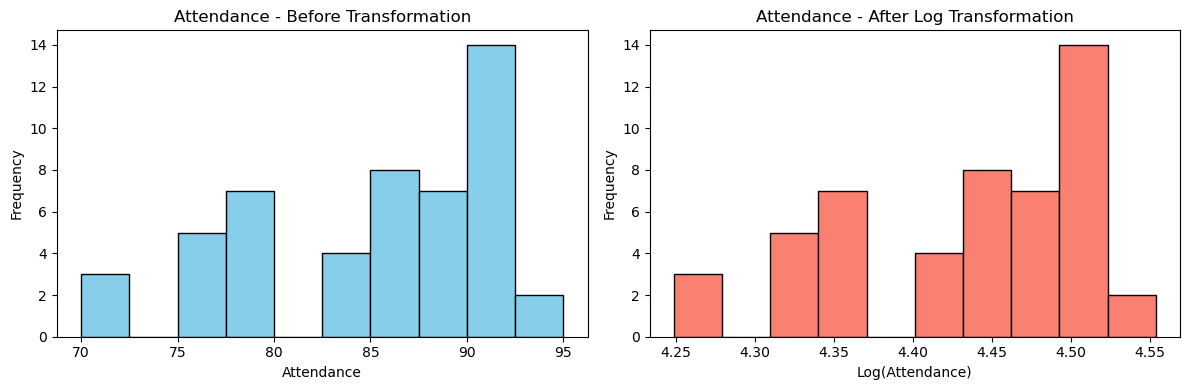

Plot saved!


In [36]:
# Step 5: Data Transformation - Log Transformation
print("\n Data Transformation")

# Check skewness before
print(f"Skewness of Attendance before: {df['Attendance'].skew():.4f}")

# Apply log transformation
df['Attendance_log'] = np.log(df['Attendance'])

print(f"Skewness of Attendance after log transform: {df['Attendance_log'].skew():.4f}")
print("\n Log transformation applied on Attendance column!")

# Plot before and after
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Attendance'], bins=10, color='skyblue', edgecolor='black')
plt.title('Attendance - Before Transformation')
plt.xlabel('Attendance')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Attendance_log'], bins=10, color='salmon', edgecolor='black')
plt.title('Attendance - After Log Transformation')
plt.xlabel('Log(Attendance)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('exp2_transformation.png')
plt.show()
print("Plot saved!")